In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [3]:
Train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
Test_df = pd.read_csv('/kaggle/input/titanic/test.csv')
gender_df = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

Now that we've added all our csv files, lets start by diving deeper into our data.

In [4]:
Train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
Train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
Test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Now let us begin by doing some exploratory data analysis!

<AxesSubplot:>

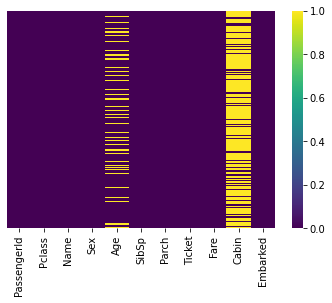

In [8]:
sns.heatmap(Test_df.isnull(), yticklabels=False, cmap="viridis")

Roughly 20 percent of the Age data is missing. The proportion of Age missing is likely small enough for reasonable replacement with some form of imputation. Looking at the Cabin column, it looks like we are just missing too much of that data to do something useful with at a basic level. We'll probably drop this later, or change it to another feature like "Cabin Known: 1 or 0"

Let's continue on by visualizing some more of the data!

<AxesSubplot:xlabel='Survived', ylabel='count'>

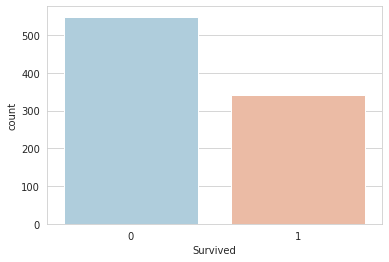

In [9]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=Train_df,palette='RdBu_r')    

<AxesSubplot:xlabel='Survived', ylabel='count'>

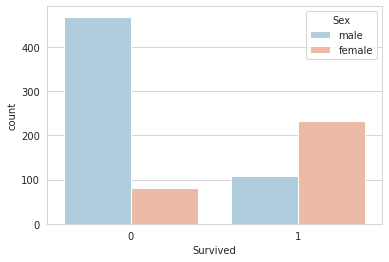

In [10]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=Train_df, palette='RdBu_r')

From the graph above, we could roughly observe that the survival rate of females is significantly higher compared to that of males.

<AxesSubplot:xlabel='Survived', ylabel='count'>

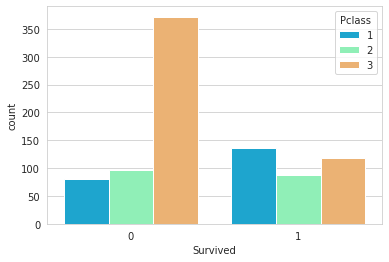

In [11]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=Train_df, palette='rainbow')

One can systematically conclude that the number of deaths were much higher for people of Class 3, whereas for Classes 1 and 2, the difference was not significant.

<AxesSubplot:>

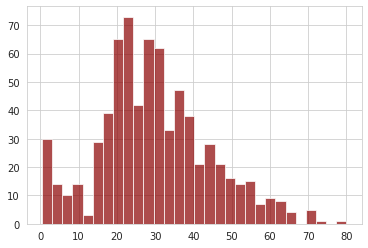

In [12]:
Train_df['Age'].hist(bins=30,color='darkred',alpha=0.7)

<AxesSubplot:xlabel='SibSp', ylabel='count'>

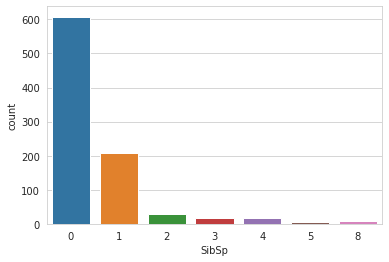

In [13]:
sns.countplot(x='SibSp',data=Train_df)

<AxesSubplot:>

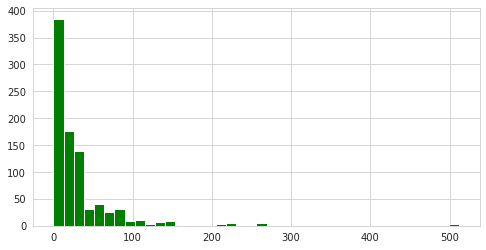

In [14]:
Train_df['Fare'].hist(color='green',bins=40,figsize=(8,4))

We want to fill in missing age data instead of just dropping the missing age data rows. One way to do this is by filling in the mean age of all the passengers (imputation). However we can be smarter about this and check the average age by passenger class. For example:

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

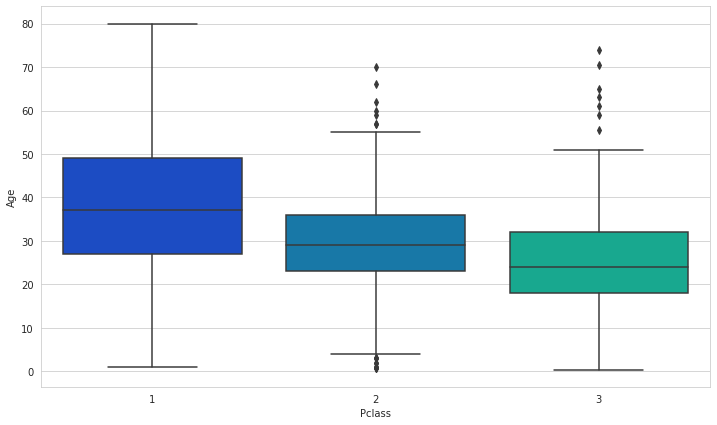

In [15]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age', data=Train_df, palette='winter')

We can see the wealthier passengers in the higher classes tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.

In [16]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24

    else:
        return Age

In [17]:
Test_df['Age'] = Test_df[['Age', 'Pclass']].apply(impute_age, axis=1)
Train_df['Age'] = Train_df[['Age','Pclass']].apply(impute_age,axis=1)

Lets check the heatmap again!

<AxesSubplot:>

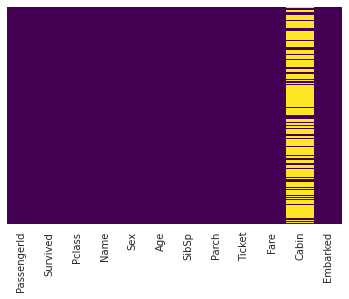

In [18]:
sns.heatmap(Train_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [19]:
Train_df.drop('Cabin', inplace=True, axis=1)
Test_df.drop('Cabin', inplace=True, axis=1)

<AxesSubplot:>

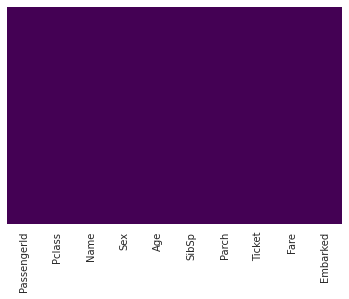

In [20]:
sns.heatmap(Test_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [21]:
Test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


In [22]:
sex1=pd.get_dummies(Train_df['Sex'], drop_first=True)
embark1=pd.get_dummies(Train_df['Embarked'], drop_first=True)

In [23]:
Train_df.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [24]:
Train_df = pd.concat([Train_df,sex1,embark1],axis=1)

In [25]:
Test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [26]:
Train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


Great!! Now our data is ready for our model!

In [27]:
Train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
male           0
Q              0
S              0
dtype: int64

In [28]:
Test_df.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

In [29]:
Test_df = Test_df.dropna()

In [30]:
Train_df.info()
Test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   male         891 non-null    uint8  
 8   Q            891 non-null    uint8  
 9   S            891 non-null    uint8  
dtypes: float64(2), int64(5), uint8(3)
memory usage: 51.5 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 417 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Pclass       417 non-null    int64  
 2   Name         417 non-null    object 
 3   Sex       

In [31]:
Train_df.drop(['male', 'Q','S'], inplace = True, axis=1)

In [32]:
Train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [33]:
Train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(Train_df.drop('Survived',axis=1), 
                                                    Train_df['Survived'], test_size=0.30, 
                                                    random_state=101)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score


In [37]:
adc = AdaBoostClassifier()
adc.fit(X_train, y_train)
Y_pred = adc.predict(X_test)
accuracy_score(Y_pred, y_test)

0.667910447761194

In [38]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
Y_pred = rfc.predict(X_test)
accuracy_score(Y_pred, y_test)

0.7313432835820896

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
print(classification_report(y_test, Y_pred))
print('\n')
print(confusion_matrix(y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.74      0.81      0.78       154
           1       0.71      0.62      0.66       114

    accuracy                           0.73       268
   macro avg       0.73      0.72      0.72       268
weighted avg       0.73      0.73      0.73       268



[[125  29]
 [ 43  71]]


In [41]:
rfc = RandomForestClassifier(n_estimators=25, max_depth=7, random_state=42)
rfc.fit(X_train, y_train)
Y_pred = rfc.predict(Test_df)

ValueError: could not convert string to float: 'Kelly, Mr. James'

In [42]:
submission = pd.DataFrame({
        "PassengerId": Test_df["PassengerId"],
        "Survived": Y_pred
    })

ValueError: array length 268 does not match index length 417

In [43]:
submission.to_csv('submission.csv', index=False)

NameError: name 'submission' is not defined

In [44]:
pd.read_csv('submission.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'submission.csv'